In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — SETUP AND LOAD
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'normal',
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

df = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')
gdf = gpd.read_file(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\sub_icb_boundaries_apr2026.geojson')

print(f"Analytical dataset: {df.shape}")
print(f"Boundary file: {gdf.shape}")
print(f"Boundary CRS: {gdf.crs}")

Analytical dataset: (106, 35)
Boundary file: (106, 11)
Boundary CRS: EPSG:4326


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — BUILD BALL MAPPER PARTITION AND JOIN TO GDF
# Single clean join — no duplicate merges
# ═══════════════════════════════════════════════════════════════════════════

# ── Ball Mapper algorithm ─────────────────────────────────────────────────
def ball_mapper(X, epsilon):
    n    = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes   = {}
    nid     = 0
    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1
    edges = []
    ids   = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))
    return nodes, edges

# ── Build point cloud and BM partition ───────────────────────────────────
variables = ['prescribing_rate_recent',
             'retail_accessibility_score',
             'imd_score_weighted']
X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
nodes_bm, _ = ball_mapper(X_scaled, 1.5)

# ── Primary node assignment ───────────────────────────────────────────────
primary_node = np.full(len(df), -1)
for nid, members in nodes_bm.items():
    for m in members:
        if primary_node[m] == -1:
            primary_node[m] = nid

node_labels = {
    0:  'N0: Consistent prescribers',
    1:  'N1: High provision, high deprivation',
    2:  'N2: Deprived withdrawers',
    3:  'N3: Extreme outlier — isolated',
    4:  'N4: Widespread low provision (deprived)',
    5:  'N5: Widespread low provision (less deprived)',
    6:  'N6: Double provision outlier',
    7:  'N7: Affluent retail-only',
    8:  'N8: Deprived NHS-dependent',
    9:  'N9: Highest prescribers',
    10: 'N10: Structural double disadvantage',
    11: 'N11: Moderate provision, least deprived',
}

# ── Add BM columns to df ──────────────────────────────────────────────────
df['bm_node']  = primary_node
df['bm_label'] = df['bm_node'].map(node_labels)

# ── Node mean prescribing for colour matching ──────────────────────────────
n_presc = {nid: df['prescribing_rate_recent'].iloc[members].mean()
           for nid, members in nodes_bm.items()}

# RdYlBu colormap matched to Ball Mapper graph
cmap_bm = plt.cm.RdYlBu
vmin_bm = min(n_presc.values())
vmax_bm = max(n_presc.values())
norm_bm = mcolors.Normalize(vmin=vmin_bm, vmax=vmax_bm)
node_colors_bm = {
    nid: mcolors.to_hex(cmap_bm(norm_bm(presc)))
    for nid, presc in n_presc.items()
}

print("Node colours matched to Ball Mapper RdYlBu prescribing scale:")
print(f"{'Node':>5} {'Mean presc':>12} {'Hex':>10}")
print("-" * 32)
for nid in sorted(n_presc.keys()):
    print(f"  N{nid:<3} {n_presc[nid]:>12.2f} {node_colors_bm[nid]:>10}")

# ── Bridge E-codes to CCG codes ───────────────────────────────────────────
lookup = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\lsoa_to_sicbl_lookup.csv')
code_bridge = lookup[['SICBL26CD', 'SICBL26CDH']].drop_duplicates()
code_bridge.columns = ['SICBL26CD', 'org_id']

# ── Single clean join: boundary + bridge + analytical data ─────────────────
gdf = gdf.merge(code_bridge, on='SICBL26CD', how='left')
gdf = gdf.merge(df, on='org_id', how='left')

print(f"\nFinal GeoDataFrame: {gdf.shape}")
print(f"BM node assigned: {gdf['bm_node'].notna().sum()} / {len(gdf)}")
print(f"CRS: {gdf.crs}")
print("Ready for choropleth mapping.")

Node colours matched to Ball Mapper RdYlBu prescribing scale:
 Node   Mean presc        Hex
--------------------------------
  N0          17.82    #81b7d7
  N1          16.27    #a6d5e7
  N2           2.03    #c82227
  N3           0.42    #a50026
  N4           3.03    #db382b
  N5           2.33    #ce2827
  N6          19.95    #5183bb
  N7           3.12    #dc3b2c
  N8          19.48    #5c90c2
  N9          22.81    #313695
  N10          2.15    #ca2427
  N11         12.44    #f3fbd4

Final GeoDataFrame: (106, 46)
BM node assigned: 106 / 106
CRS: EPSG:4326
Ready for choropleth mapping.


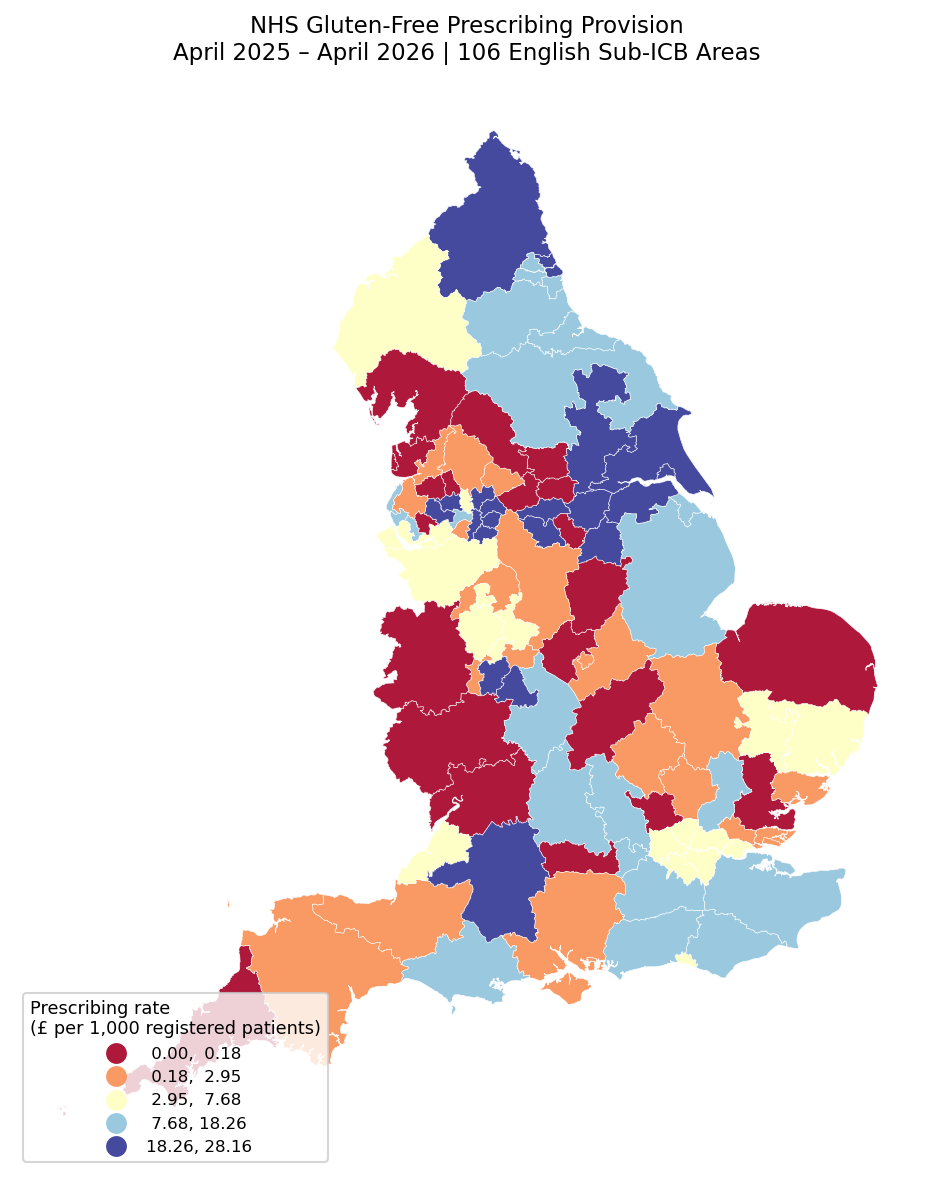

Saved MAP_01a_prescribing.png.


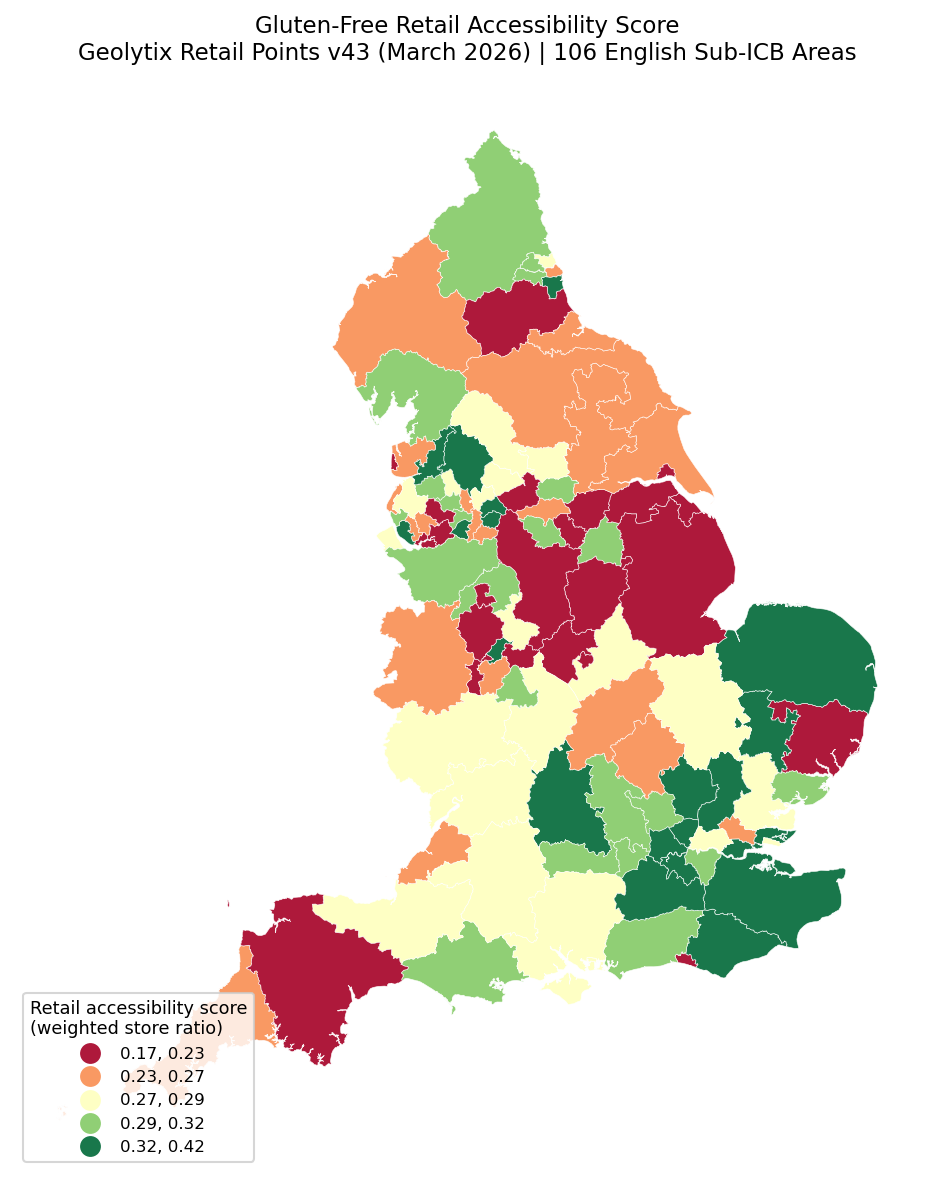

Saved MAP_01b_retail.png.


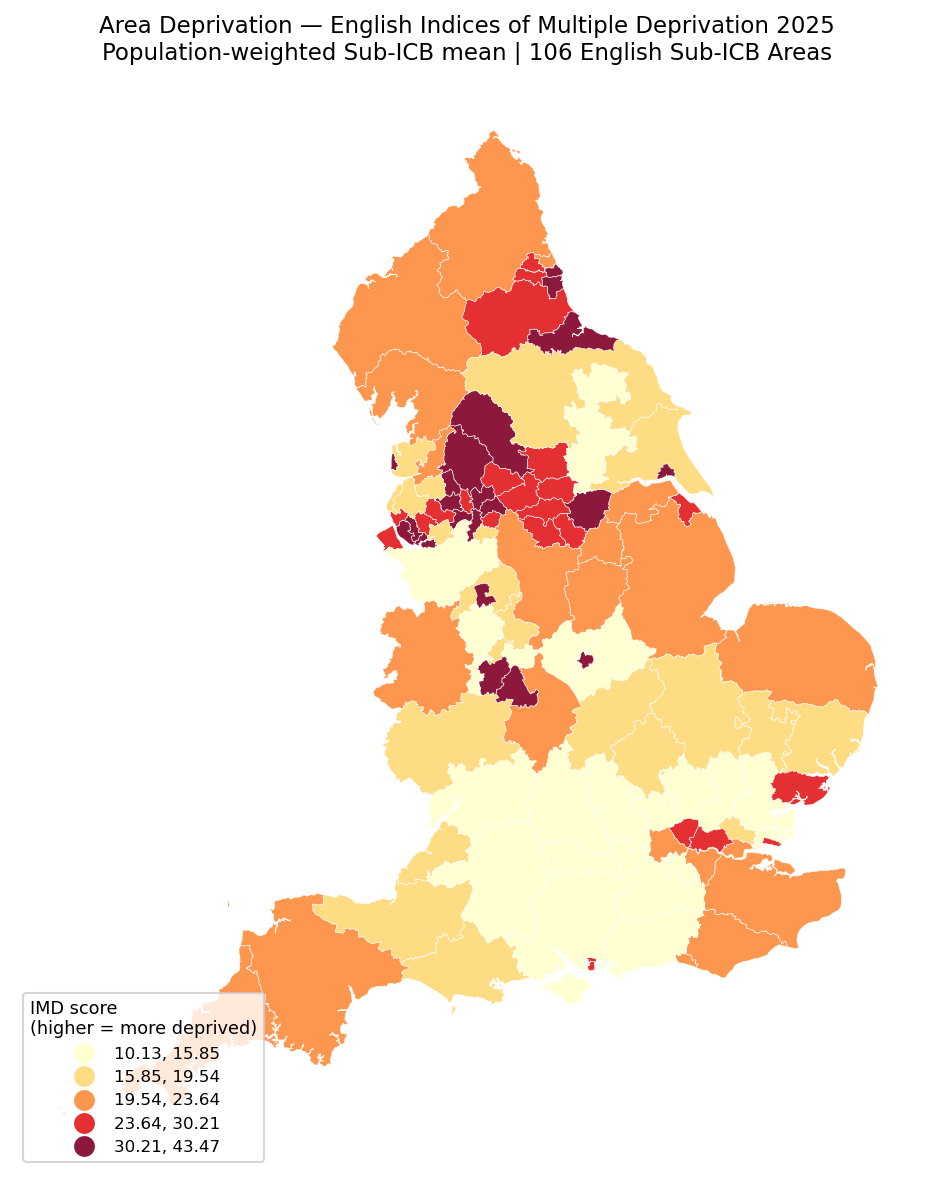

Saved MAP_01c_imd.png.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — THREE AXIS CHOROPLETH MAPS (separate figures)
# ═══════════════════════════════════════════════════════════════════════════

def choropleth_map(gdf, column, cmap, title, cbar_label, filename,
                   scheme='quantiles', k=5):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    gdf.plot(column=column, ax=ax, cmap=cmap,
             scheme=scheme, k=k, legend=True,
             legend_kwds={
                 'title': cbar_label,
                 'loc': 'lower left',
                 'fontsize': 8, 'title_fontsize': 8.5,
                 'fmt': '{:.2f}',
             },
             edgecolor='white', linewidth=0.3, alpha=0.9)
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(f'{FIG_PATH}/{filename}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved {filename}.")

choropleth_map(
    gdf, 'prescribing_rate_recent', 'RdYlBu',
    'NHS Gluten-Free Prescribing Provision\n'
    'April 2025 – April 2026 | 106 English Sub-ICB Areas',
    'Prescribing rate\n(£ per 1,000 registered patients)',
    'MAP_01a_prescribing.png')

choropleth_map(
    gdf, 'retail_accessibility_score', 'RdYlGn',
    'Gluten-Free Retail Accessibility Score\n'
    'Geolytix Retail Points v43 (March 2026) | 106 English Sub-ICB Areas',
    'Retail accessibility score\n(weighted store ratio)',
    'MAP_01b_retail.png')

choropleth_map(
    gdf, 'imd_score_weighted', 'YlOrRd',
    'Area Deprivation — English Indices of Multiple Deprivation 2025\n'
    'Population-weighted Sub-ICB mean | 106 English Sub-ICB Areas',
    'IMD score\n(higher = more deprived)',
    'MAP_01c_imd.png')

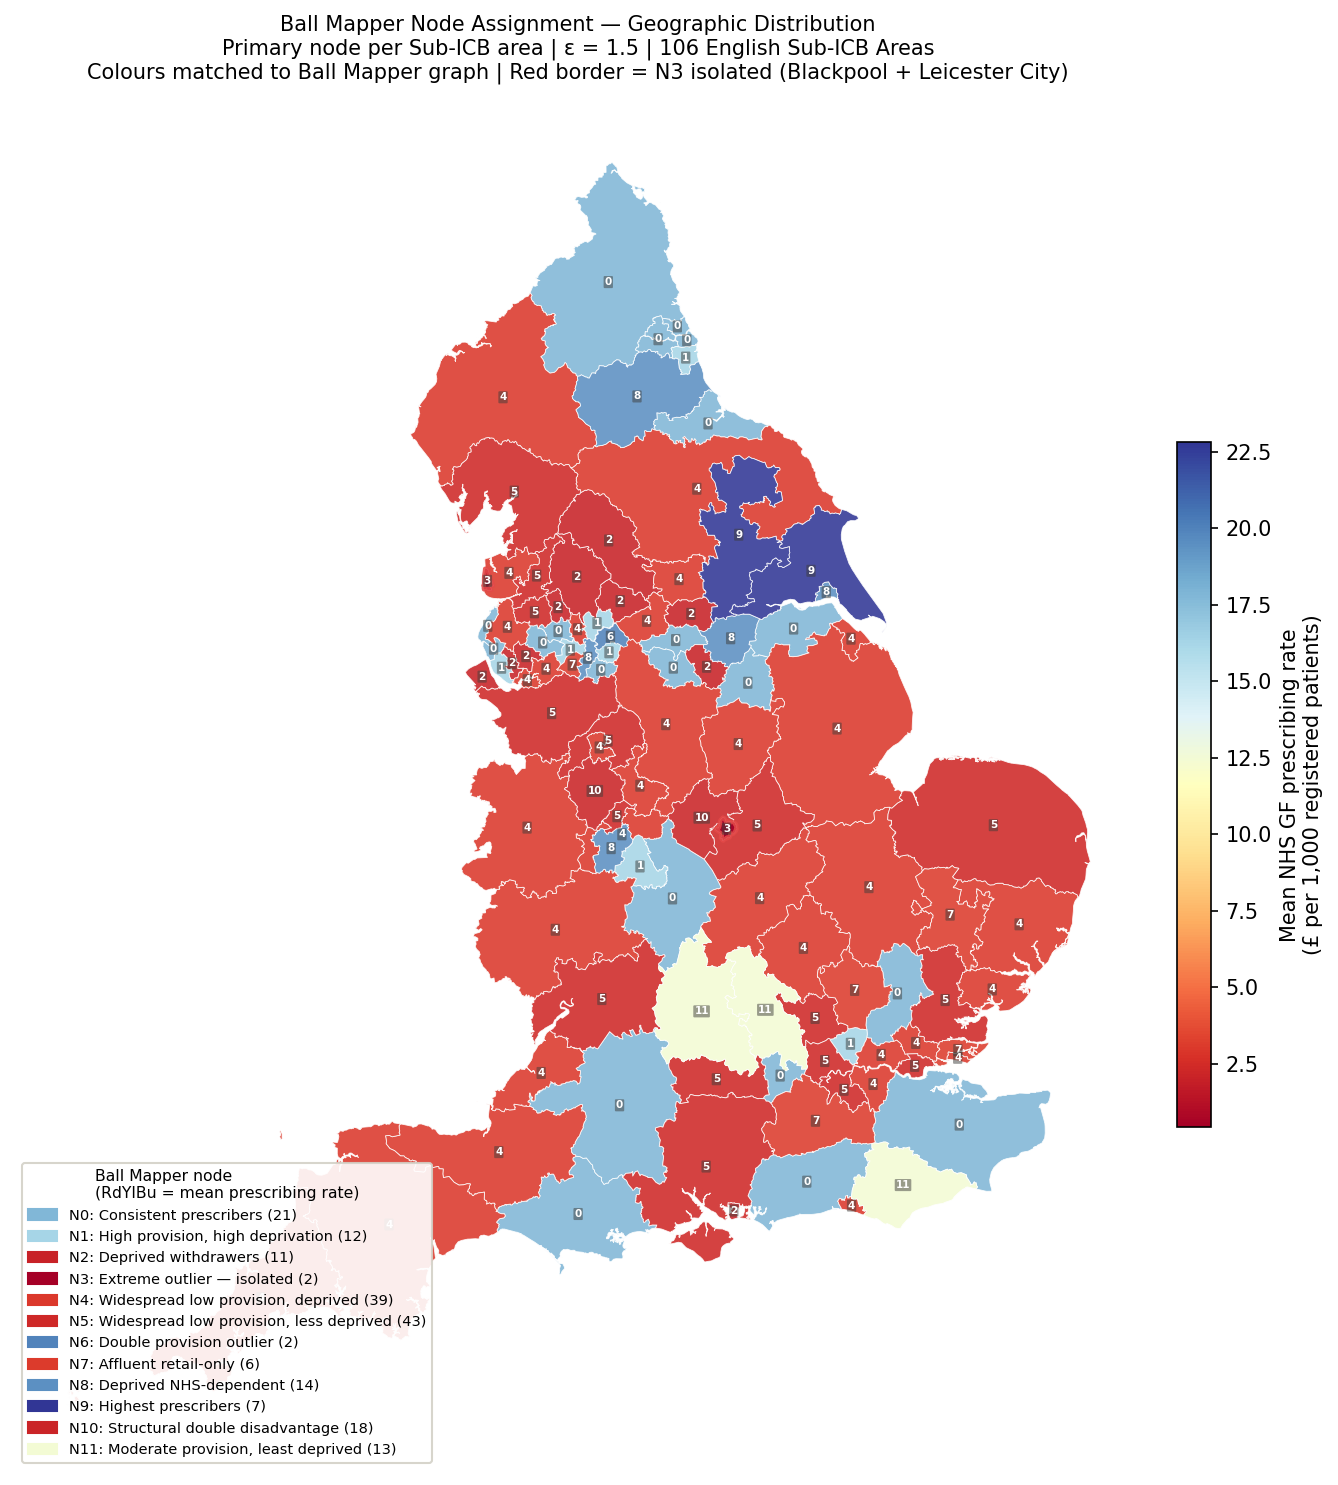

Saved MAP_02.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — BALL MAPPER NODE ASSIGNMENT MAP
# Colours matched to Ball Mapper graph (RdYlBu by mean prescribing rate)
# No additional merge needed — bm_node already in gdf from Cell 2
# ═══════════════════════════════════════════════════════════════════════════

node_labels_map = {
    0:  'N0: Consistent prescribers (21)',
    1:  'N1: High provision, high deprivation (12)',
    2:  'N2: Deprived withdrawers (11)',
    3:  'N3: Extreme outlier — isolated (2)',
    4:  'N4: Widespread low provision, deprived (39)',
    5:  'N5: Widespread low provision, less deprived (43)',
    6:  'N6: Double provision outlier (2)',
    7:  'N7: Affluent retail-only (6)',
    8:  'N8: Deprived NHS-dependent (14)',
    9:  'N9: Highest prescribers (7)',
    10: 'N10: Structural double disadvantage (18)',
    11: 'N11: Moderate provision, least deprived (13)',
}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for nid in sorted(node_colors_bm.keys()):
    subset = gdf[gdf['bm_node'] == nid]
    if len(subset) > 0:
        subset.plot(ax=ax, color=node_colors_bm[nid],
                    edgecolor='white', linewidth=0.4, alpha=0.88)

# Red border for isolated N3
n3_subset = gdf[gdf['bm_node'] == 3]
if len(n3_subset) > 0:
    n3_subset.plot(ax=ax, color=node_colors_bm[3],
                   edgecolor='#e34948', linewidth=2.0, alpha=0.88)

# Legend
handles = [
    mpatches.Patch(color=node_colors_bm[nid],
                   label=node_labels_map[nid])
    for nid in sorted(node_colors_bm.keys())
    if len(gdf[gdf['bm_node'] == nid]) > 0
]
ax.legend(handles=handles, loc='lower left', fontsize=7,
          title='Ball Mapper node\n(RdYlBu = mean prescribing rate)',
          title_fontsize=7.5,
          framealpha=0.9, edgecolor='#d3d1c7')

# Colorbar matching Ball Mapper scale
sm = plt.cm.ScalarMappable(cmap=cmap_bm, norm=norm_bm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02,
             label='Mean NHS GF prescribing rate\n(£ per 1,000 registered patients)')

ax.set_title(
    'Ball Mapper Node Assignment — Geographic Distribution\n'
    'Primary node per Sub-ICB area | ε = 1.5 | 106 English Sub-ICB Areas\n'
    'Colours matched to Ball Mapper graph | Red border = N3 isolated '
    '(Blackpool + Leicester City)',
    fontsize=10, pad=10)
ax.set_axis_off()

# ── Label every Sub-ICB area with its node number ─────────────────────────
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        str(int(row['bm_node'])),
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=5, fontweight='bold',
        color='white',
        bbox=dict(boxstyle='round,pad=0.1',
                  facecolor='#3d3d3a',
                  edgecolor='none',
                  alpha=0.5))
        
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_02_ballmapper_nodes.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_02.")

Computing LISA for prescribing provision...
Computing LISA for retail accessibility...

LISA Results — Prescribing Provision:
Not significant    84
High-High          19
Low-Low             3

LISA Results — Retail Accessibility:
Not significant    77
High-High          16
Low-Low            13


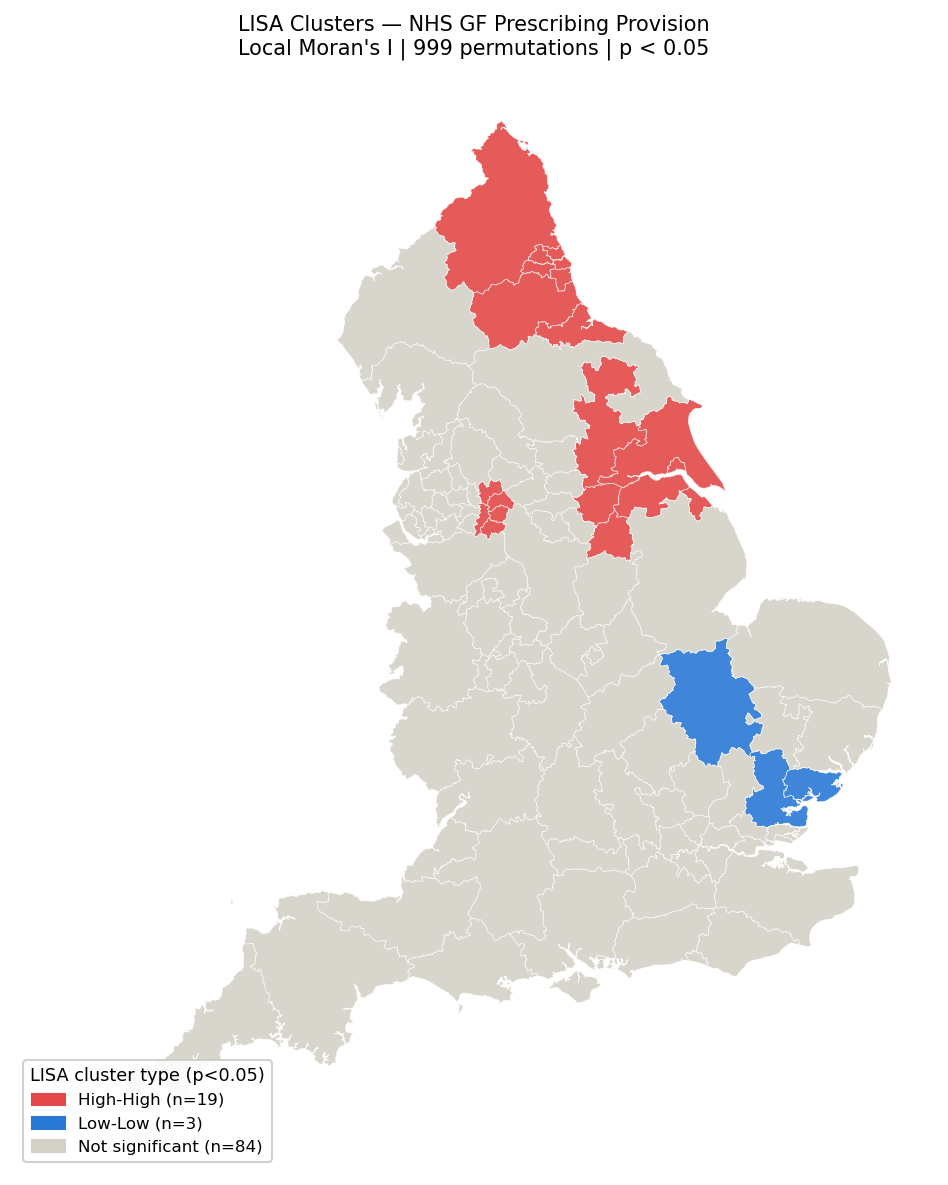

Saved MAP_03a.


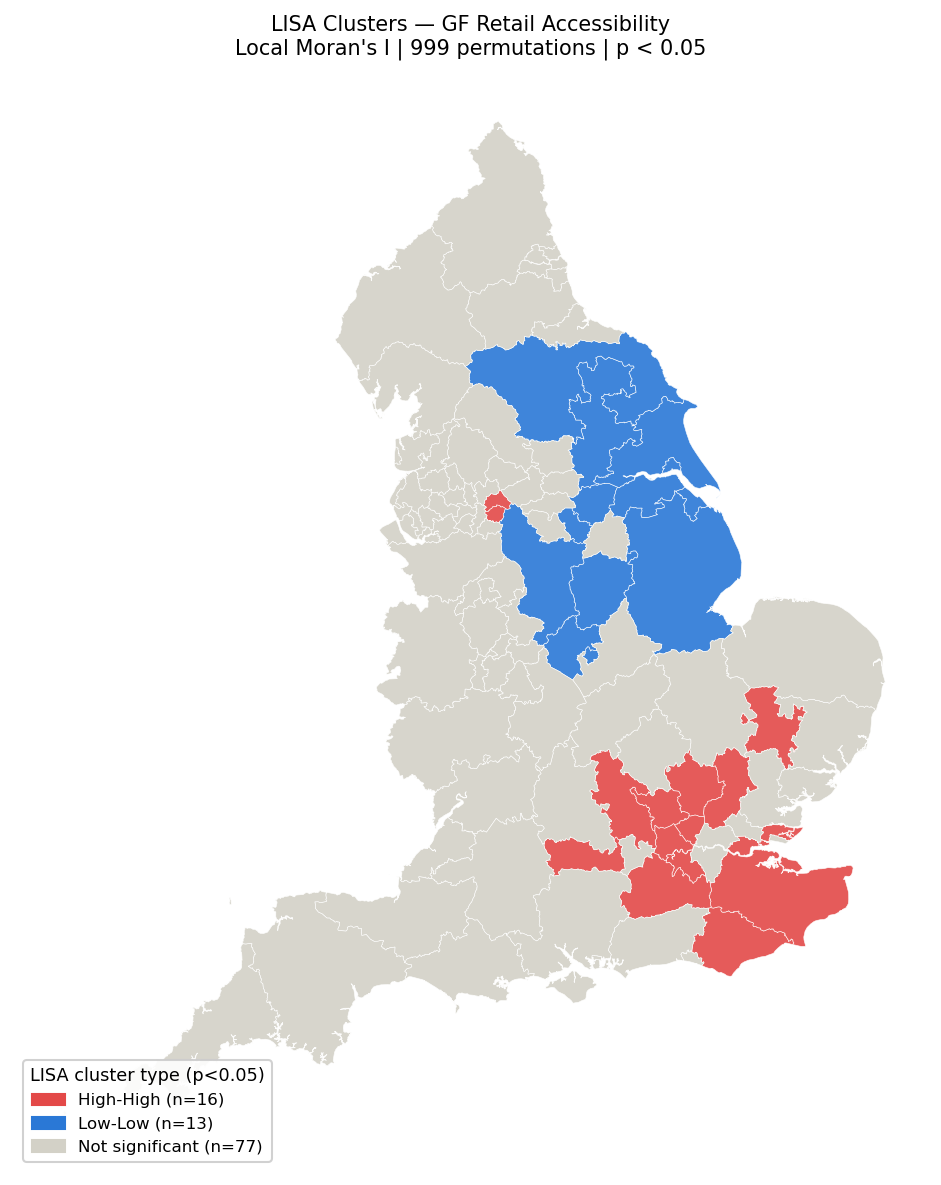

Saved MAP_03b.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — LISA LOCAL SPATIAL AUTOCORRELATION
# Local Indicators of Spatial Association for prescribing and retail
# Identifies statistically significant local clusters and outliers
# Following Anselin (1995)
# ═══════════════════════════════════════════════════════════════════════════

from scipy.spatial.distance import cdist

# ── Spatial weights matrix (inverse distance) ─────────────────────────────
coords      = gdf[['centroid_lon', 'centroid_lat']].values
dist_matrix = cdist(coords, coords, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)
W           = 1 / dist_matrix
np.fill_diagonal(W, 0)
W_std       = W / W.sum(axis=1, keepdims=True)

def local_morans_i(values, W, n_perm=999):
    """
    Local Moran's I (LISA) for each observation.
    Returns local I, z-score, p-value, and cluster type.
    Following Anselin (1995).
    """
    n    = len(values)
    z    = (values - values.mean()) / values.std()
    Ii   = z * (W_std @ z)
    
    # Permutation test for each location
    np.random.seed(42)
    Ii_perm = np.zeros((n_perm, n))
    for p in range(n_perm):
        z_perm     = np.random.permutation(z)
        Ii_perm[p] = z_perm * (W_std @ z_perm)
    
    p_values = np.mean(Ii_perm >= Ii, axis=0)
    z_scores = (Ii - Ii_perm.mean(axis=0)) / Ii_perm.std(axis=0)
    
    # Cluster type classification
    Wz       = W_std @ z
    sig      = p_values < 0.05
    cluster  = np.full(n, 'Not significant', dtype=object)
    cluster[(z > 0) & (Wz > 0) & sig] = 'High-High'
    cluster[(z < 0) & (Wz < 0) & sig] = 'Low-Low'
    cluster[(z > 0) & (Wz < 0) & sig] = 'High-Low'
    cluster[(z < 0) & (Wz > 0) & sig] = 'Low-High'
    
    return Ii, z_scores, p_values, cluster

# ── Compute LISA for prescribing and retail ────────────────────────────────
print("Computing LISA for prescribing provision...")
presc_vals = gdf['prescribing_rate_recent'].values
Ii_p, z_p, pv_p, cl_p = local_morans_i(presc_vals, W_std)
gdf['lisa_presc_cluster'] = cl_p
gdf['lisa_presc_pvalue']  = pv_p

print("Computing LISA for retail accessibility...")
retail_vals = gdf['retail_accessibility_score'].values
Ii_r, z_r, pv_r, cl_r = local_morans_i(retail_vals, W_std)
gdf['lisa_retail_cluster'] = cl_r
gdf['lisa_retail_pvalue']  = pv_r

# ── Print summary ──────────────────────────────────────────────────────────
print("\nLISA Results — Prescribing Provision:")
print(pd.Series(cl_p).value_counts().to_string())

print("\nLISA Results — Retail Accessibility:")
print(pd.Series(cl_r).value_counts().to_string())

# ── LISA cluster maps ──────────────────────────────────────────────────────
lisa_colors = {
    'High-High':       '#e34948',
    'Low-Low':         '#2a78d6',
    'High-Low':        '#eda100',
    'Low-High':        '#1baf7a',
    'Not significant': '#d3d1c7',
}

def lisa_map(ax, gdf, cluster_col, title):
    for cluster_type, color in lisa_colors.items():
        subset = gdf[gdf[cluster_col] == cluster_type]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color,
                       edgecolor='white', linewidth=0.3, alpha=0.9)
    handles = [
        mpatches.Patch(color=c, label=f'{ct} (n={len(gdf[gdf[cluster_col]==ct])})')
        for ct, c in lisa_colors.items()
        if len(gdf[gdf[cluster_col] == ct]) > 0
    ]
    ax.legend(handles=handles, loc='lower left', fontsize=8,
              title='LISA cluster type (p<0.05)',
              title_fontsize=8.5, framealpha=0.9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_axis_off()

# Map 1 — Prescribing LISA
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
lisa_map(ax, gdf, 'lisa_presc_cluster',
         'LISA Clusters — NHS GF Prescribing Provision\n'
         'Local Moran\'s I | 999 permutations | p < 0.05')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03a_lisa_prescribing.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03a.")

# Map 2 — Retail LISA
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
lisa_map(ax, gdf, 'lisa_retail_cluster',
         'LISA Clusters — GF Retail Accessibility\n'
         'Local Moran\'s I | 999 permutations | p < 0.05')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03b_lisa_retail.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03b.")

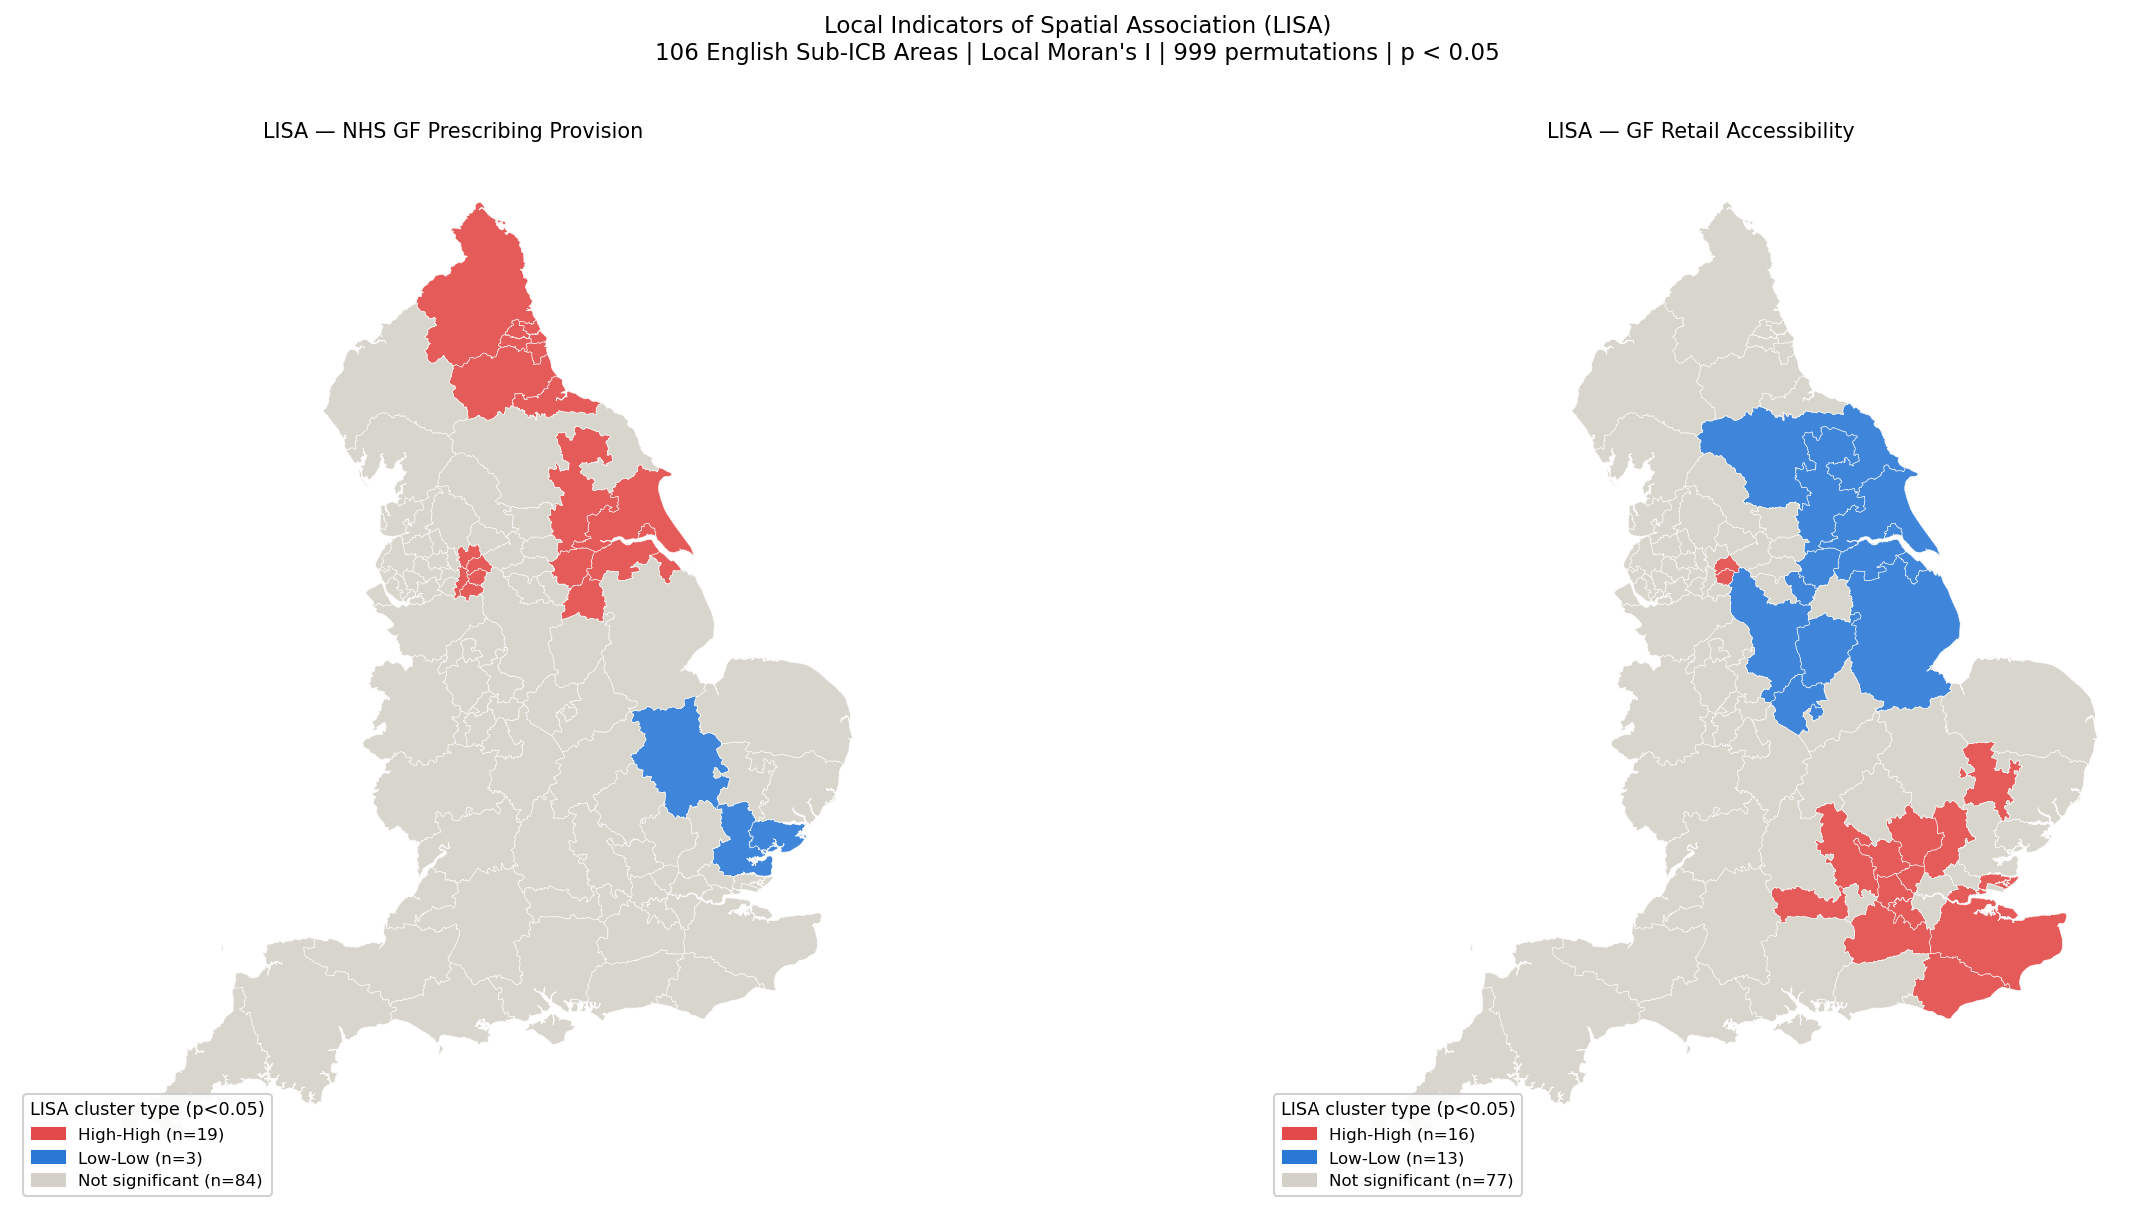

Saved MAP_03_lisa_combined.
Saved LISA_results.csv
Updated analytical_dataset_final.csv

Figures saved in this notebook:
  outputs/figures/MAP_01a_prescribing.png
  outputs/figures/MAP_01b_retail.png
  outputs/figures/MAP_01c_imd.png
  outputs/figures/MAP_02_ballmapper_nodes.png
  outputs/figures/MAP_03a_lisa_prescribing.png
  outputs/figures/MAP_03b_lisa_retail.png
  outputs/figures/MAP_03_lisa_combined.png

Tables saved:
  outputs/tables/LISA_results.csv

LISA summary:
  Prescribing HH: 19 | LL: 3 | NS: 84
  Retail HH: 16 | LL: 13 | NS: 77

Notebook 05 complete. Ready to commit.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — COMBINED LISA MAP AND FINAL SAVE
# ═══════════════════════════════════════════════════════════════════════════

# Combined side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

lisa_map(axes[0], gdf, 'lisa_presc_cluster',
         'LISA — NHS GF Prescribing Provision')
lisa_map(axes[1], gdf, 'lisa_retail_cluster',
         'LISA — GF Retail Accessibility')

plt.suptitle(
    'Local Indicators of Spatial Association (LISA)\n'
    '106 English Sub-ICB Areas | Local Moran\'s I | '
    '999 permutations | p < 0.05',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/MAP_03_lisa_combined.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved MAP_03_lisa_combined.")

# Save LISA results
lisa_results = gdf[['org_id', 'org_name',
                     'lisa_presc_cluster', 'lisa_presc_pvalue',
                     'lisa_retail_cluster', 'lisa_retail_pvalue']].copy()
lisa_results.to_csv(f'{TAB_PATH}/LISA_results.csv', index=False)
print("Saved LISA_results.csv")

# Update analytical dataset
df_updated = df.merge(
    lisa_results[['org_id', 'lisa_presc_cluster', 'lisa_retail_cluster']],
    on='org_id', how='left')
df_updated.to_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv',
    index=False)
print("Updated analytical_dataset_final.csv")

# Summary
print("\nFigures saved in this notebook:")
for f in ['MAP_01a_prescribing.png', 'MAP_01b_retail.png',
          'MAP_01c_imd.png', 'MAP_02_ballmapper_nodes.png',
          'MAP_03a_lisa_prescribing.png', 'MAP_03b_lisa_retail.png',
          'MAP_03_lisa_combined.png']:
    print(f"  outputs/figures/{f}")

print("\nTables saved:")
print("  outputs/tables/LISA_results.csv")

print(f"\nLISA summary:")
print(f"  Prescribing HH: {(gdf['lisa_presc_cluster']=='High-High').sum()} | "
      f"LL: {(gdf['lisa_presc_cluster']=='Low-Low').sum()} | "
      f"NS: {(gdf['lisa_presc_cluster']=='Not significant').sum()}")
print(f"  Retail HH: {(gdf['lisa_retail_cluster']=='High-High').sum()} | "
      f"LL: {(gdf['lisa_retail_cluster']=='Low-Low').sum()} | "
      f"NS: {(gdf['lisa_retail_cluster']=='Not significant').sum()}")

print("\nNotebook 05 complete. Ready to commit.")

In [9]:
pip install folium


  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [16]:
# ── Load R primary partition ───────────────────────────────────────────────
import pandas as pd

primary_r = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables\BM_R_primary_partition.csv'
)

df = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv'
)

# Drop existing bm_node and merge R primary partition
if 'bm_node' in df.columns:
    df = df.drop(columns=['bm_node'])

df = df.merge(primary_r, on='org_id', how='left')

print("Final node assignment counts (R primary partition):")
print(df['bm_node'].value_counts().sort_index())
print(f"Total: {df['bm_node'].notna().sum()} / {len(df)}")

df.to_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv',
    index=False
)
print("\nUpdated analytical_dataset_final.csv")

Final node assignment counts (R primary partition):
bm_node
0     22
1      7
2     10
3      2
4     32
5     16
6      1
7      5
8      5
9      2
10     2
11     2
Name: count, dtype: int64
Total: 106 / 106

Updated analytical_dataset_final.csv


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# INTERACTIVE BALL MAPPER NODE MAP (FOLIUM) — UPDATED
# R primary partition | Node filter via LayerControl
# ═══════════════════════════════════════════════════════════════════════════

import folium
from folium import FeatureGroup, LayerControl
import numpy as np

# ── Node colours matched to R annotated graph (RdYlBu by mean prescribing) ─
node_mean_presc = {}
bm_r = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables\BM_R_node_membership.csv'
)
for nid in sorted(bm_r['node_id'].unique()):
    node_mean_presc[nid] = bm_r[bm_r['node_id'] == nid]['prescribing_rate_recent'].mean()

vmin = min(node_mean_presc.values())
vmax = max(node_mean_presc.values())

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = plt.cm.RdYlBu

def presc_to_hex(presc):
    norm = (presc - vmin) / (vmax - vmin)
    rgba = cmap(norm)
    return mcolors.to_hex(rgba)

node_colors_map = {nid: presc_to_hex(presc)
                   for nid, presc in node_mean_presc.items()}

# ── Node labels ────────────────────────────────────────────────────────────
node_labels = {
    0:  'Consistent prescribers',
    1:  'High provision, high deprivation',
    2:  'Deprived withdrawers',
    3:  'Extreme outlier',
    4:  'Low provision (deprived)',
    5:  'Low provision (less deprived)',
    6:  'Double provision outlier',
    7:  'Affluent retail-only',
    8:  'Deprived NHS-dependent',
    9:  'Highest prescribers',
    10: 'Structural double disadvantage',
    11: 'Moderate provision, least deprived',
}

# ── Base map ───────────────────────────────────────────────────────────────
m = folium.Map(
    location=[52.8, -1.5],
    zoom_start=6,
    tiles='CartoDB positron')

# ── One FeatureGroup per node — enables click-to-filter ───────────────────
for nid in sorted(node_colors_map.keys()):
    color   = node_colors_map[nid]
    label   = node_labels[nid]
    subset  = gdf[gdf['bm_node'] == nid]

    if len(subset) == 0:
        continue

    fg = FeatureGroup(name=f"N{nid}: {label}", show=True)

    for _, row in subset.iterrows():
        org_name = row['org_name'].replace('NHS ', '')

        tooltip = folium.Tooltip(
            f"<b>{org_name}</b><br>"
            f"Node N{nid}: {label}<br>"
            f"Prescribing: £{row['prescribing_rate_recent']:.2f}<br>"
            f"Retail score: {row['retail_accessibility_score']:.3f}<br>"
            f"IMD: {row['imd_score_weighted']:.1f}<br>"
            f"Withdrawal count: {int(row['months_zero'])} months"
        )

        popup = folium.Popup(
            f"<b>{org_name}</b><br>"
            f"<b>N{nid}:</b> {label}<br><br>"
            f"Prescribing rate: £{row['prescribing_rate_recent']:.2f}<br>"
            f"Retail accessibility: {row['retail_accessibility_score']:.3f}<br>"
            f"IMD score: {row['imd_score_weighted']:.1f}<br>"
            f"Withdrawal count: {int(row['months_zero'])} months<br>"
            f"Trend slope: {row['trend_slope']:.4f}",
            max_width=250
        )

        folium.GeoJson(
            row['geometry'].__geo_interface__,
            style_function=lambda x, c=color: {
                'fillColor':   c,
                'color':       '#ffffff',
                'weight':      0.5,
                'fillOpacity': 0.85,
            },
            highlight_function=lambda x: {
                'weight':      2.5,
                'color':       '#333333',
                'fillOpacity': 1.0,
            },
            tooltip=tooltip,
            popup=popup,
        ).add_to(fg)

    fg.add_to(m)

# ── Layer control — acts as node filter ───────────────────────────────────
LayerControl(
    position='topright',
    collapsed=False
).add_to(m)

# ── Legend (bottom left) ──────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 11px; max-width: 240px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
<b>Ball Mapper Nodes (ε = 1.5)</b><br>
<i style="font-size:10px">Coloured by mean prescribing rate</i><br>
<i style="font-size:10px">Use layer panel (top right) to filter nodes</i><br><br>
"""

for nid in sorted(node_colors_map.keys()):
    color = node_colors_map[nid]
    label = node_labels[nid]
    iso   = ' ⚠' if nid == 3 else ''
    legend_html += (
        f'<span style="background:{color};display:inline-block;'
        f'width:12px;height:12px;border-radius:2px;margin-right:5px;"></span>'
        f'N{nid}: {label}{iso}<br>'
    )

legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

# ── Save ──────────────────────────────────────────────────────────────────
output_path = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\MAP_02_interactive.html'
m.save(output_path)
print(f"Saved interactive map to {output_path}")
print("Open in browser — hover for tooltips, click for popups,")
print("use layer panel (top right) to show/hide individual nodes.")

Saved interactive map to C:\Users\namra\gluten-free-spatial-inequality\outputs\figures\MAP_02_interactive.html
Open in browser — hover for tooltips, click for popups,
use layer panel (top right) to show/hide individual nodes.
